# Lab 4: Salary Prediction using Linear, Ridge, and Lasso Regression

### Objective:
1. Load and explore the Salary dataset (`Salary_Data.csv`).
2. Train and evaluate:
   - **Linear Regression (Ordinary Least Squares)**
   - **Ridge Regression (L2 Regularization)**
   - **Lasso Regression (L1 Regularization)**
3. Compute and compare performance error metrics for each model:
   - **Mean Absolute Error (MAE)**
   - **Mean Squared Error (MSE)**
   - **Root Mean Squared Error (RMSE)**
   - **$R^2$ Score (Accuracy / Goodness of Fit)**
4. Visualize regression fit lines and compare model errors.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset
data = pd.read_csv('Salary_Data.csv')
df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (30, 2)

First 5 Rows:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes

Summary Statistics:
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000

Missing Values:
YearsExperience    0
Salary             0
dtype: int64


In [4]:
# Define features (X) and target variable (y)
X = df[['YearsExperience']]
y = df['Salary']

# Split into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = x_train, x_test

print(f"Total samples   : {len(df)}")
print(f"Training samples: {len(x_train)}")
print(f"Testing samples : {len(x_test)}")

Total samples   : 30
Training samples: 24
Testing samples : 6


In [5]:
# 1. Linear Regression (OLS)
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(x_test)
y_pred = y_pred_lr

# Model parameters
lr_intercept = lr_model.intercept_
lr_coef = lr_model.coef_[0]

# Error Metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print(f"Intercept (c)            : {lr_intercept:.4f}")
print(f"Slope (m)                : {lr_coef:.4f}")
print(f"Equation                 : Salary = {lr_coef:.4f} * YearsExperience + {lr_intercept:.4f}")
print(f"Mean Absolute Error (MAE): {lr_mae:.4f}")
print(f"Mean Squared Error (MSE) : {lr_mse:.4f}")
print(f"Root Mean Squared (RMSE) : {lr_rmse:.4f}")
print(f"R2 Score                 : {lr_r2:.4f}")

=== Linear Regression ===
Intercept (c)            : 25321.5830
Slope (m)                : 9423.8153
Equation                 : Salary = 9423.8153 * YearsExperience + 25321.5830
Mean Absolute Error (MAE): 6286.4538
Mean Squared Error (MSE) : 49830096.8559
Root Mean Squared (RMSE) : 7059.0436
R2 Score                 : 0.9024


In [6]:
# 2. Ridge Regression (L2 Regularization)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(x_test)

# Model parameters
ridge_intercept = ridge_model.intercept_
ridge_coef = ridge_model.coef_[0]

# Error Metrics
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("=== Ridge Regression (alpha=1.0) ===")
print(f"Intercept (c)            : {ridge_intercept:.4f}")
print(f"Slope (m)                : {ridge_coef:.4f}")
print(f"Equation                 : Salary = {ridge_coef:.4f} * YearsExperience + {ridge_intercept:.4f}")
print(f"Mean Absolute Error (MAE): {ridge_mae:.4f}")
print(f"Mean Squared Error (MSE) : {ridge_mse:.4f}")
print(f"Root Mean Squared (RMSE) : {ridge_rmse:.4f}")
print(f"R2 Score                 : {ridge_r2:.4f}")

=== Ridge Regression (alpha=1.0) ===
Intercept (c)            : 25565.7370
Slope (m)                : 9376.7495
Equation                 : Salary = 9376.7495 * YearsExperience + 25565.7370
Mean Absolute Error (MAE): 6274.6874
Mean Squared Error (MSE) : 49974852.7200
Root Mean Squared (RMSE) : 7069.2894
R2 Score                 : 0.9022


In [7]:
# 3. Lasso Regression (L1 Regularization)
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(x_train, y_train)

# Predictions
y_pred_lasso = lasso_model.predict(x_test)

# Model parameters
lasso_intercept = lasso_model.intercept_
lasso_coef = lasso_model.coef_[0]

# Error Metrics
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("=== Lasso Regression (alpha=1.0) ===")
print(f"Intercept (c)            : {lasso_intercept:.4f}")
print(f"Slope (m)                : {lasso_coef:.4f}")
print(f"Equation                 : Salary = {lasso_coef:.4f} * YearsExperience + {lasso_intercept:.4f}")
print(f"Mean Absolute Error (MAE): {lasso_mae:.4f}")
print(f"Mean Squared Error (MSE) : {lasso_mse:.4f}")
print(f"Root Mean Squared (RMSE) : {lasso_rmse:.4f}")
print(f"R2 Score                 : {lasso_r2:.4f}")

=== Lasso Regression (alpha=1.0) ===
Intercept (c)            : 25322.2079
Slope (m)                : 9423.6949
Equation                 : Salary = 9423.6949 * YearsExperience + 25322.2079
Mean Absolute Error (MAE): 6286.4237
Mean Squared Error (MSE) : 49830434.5577
Root Mean Squared (RMSE) : 7059.0675
R2 Score                 : 0.9024


In [8]:
# Comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression (L2)', 'Lasso Regression (L1)'],
    'Intercept': [lr_intercept, ridge_intercept, lasso_intercept],
    'Slope (Coef)': [lr_coef, ridge_coef, lasso_coef],
    'MAE': [lr_mae, ridge_mae, lasso_mae],
    'MSE': [lr_mse, ridge_mse, lasso_mse],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2]
})

print("=== Comprehensive Model & Error Comparison ===")
print(comparison_df.to_string(index=False))

=== Comprehensive Model & Error Comparison ===
                Model    Intercept  Slope (Coef)         MAE          MSE        RMSE  R2 Score
    Linear Regression 25321.583012   9423.815323 6286.453831 4.983010e+07 7059.043622  0.902446
Ridge Regression (L2) 25565.737022   9376.749490 6274.687372 4.997485e+07 7069.289407  0.902163
Lasso Regression (L1) 25322.207929   9423.694857 6286.423714 4.983043e+07 7059.067542  0.902446


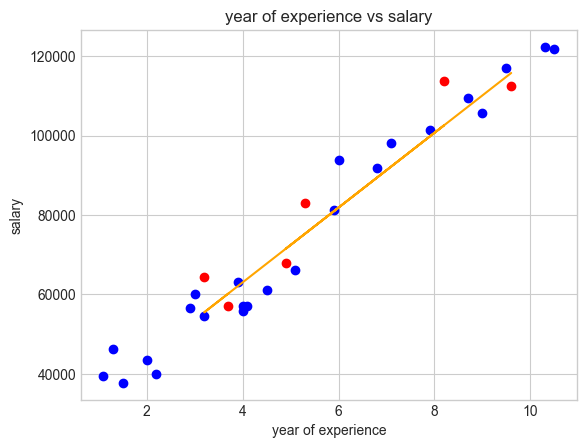

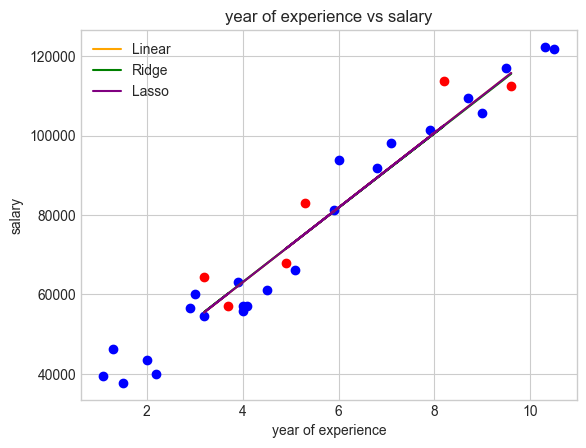

In [9]:
import matplotlib.pyplot as plt

# 1. Linear Regression Plot
plt.scatter(x_train, y_train, color="blue")
plt.scatter(x_test, y_test, color='red')
plt.plot(x_test, y_pred, color="orange")

plt.xlabel("year of experience")
plt.ylabel("salary")
plt.title("year of experience vs salary")
plt.show()

# 2. Linear, Ridge, and Lasso plotted together
plt.scatter(x_train, y_train, color="blue")
plt.scatter(x_test, y_test, color='red')
plt.plot(x_test, y_pred_lr, color="orange", label="Linear")
plt.plot(x_test, y_pred_ridge, color="green", label="Ridge")
plt.plot(x_test, y_pred_lasso, color="purple", label="Lasso")

plt.xlabel("year of experience")
plt.ylabel("salary")
plt.title("year of experience vs salary")
plt.legend()
plt.show()

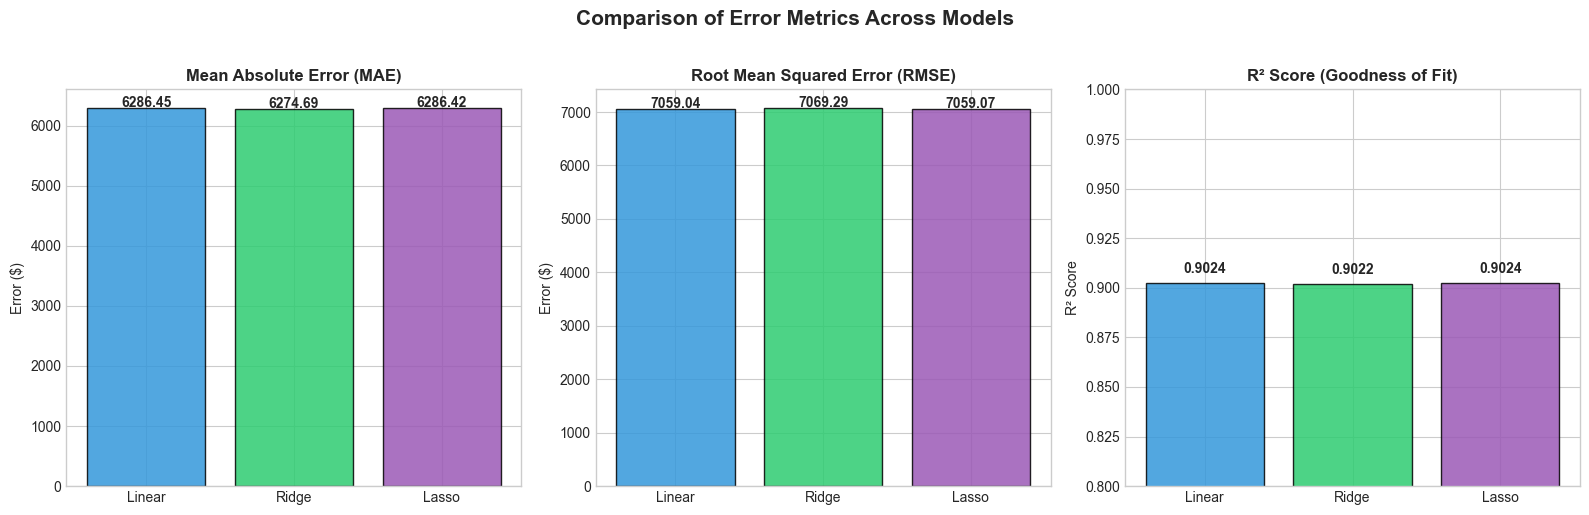

In [10]:
# Error comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['Linear', 'Ridge', 'Lasso']
colors = ['#3498db', '#2ecc71', '#9b59b6']

# 1. MAE Comparison
axes[0].bar(models, [lr_mae, ridge_mae, lasso_mae], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Error ($)')
for i, v in enumerate([lr_mae, ridge_mae, lasso_mae]):
    axes[0].text(i, v + 20, f"{v:.2f}", ha='center', fontweight='bold')

# 2. RMSE Comparison
axes[1].bar(models, [lr_rmse, ridge_rmse, lasso_rmse], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Error ($)')
for i, v in enumerate([lr_rmse, ridge_rmse, lasso_rmse]):
    axes[1].text(i, v + 25, f"{v:.2f}", ha='center', fontweight='bold')

# 3. R2 Score Comparison
axes[2].bar(models, [lr_r2, ridge_r2, lasso_r2], color=colors, edgecolor='black', alpha=0.85)
axes[2].set_title('R² Score (Goodness of Fit)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim([0.8, 1.0])
for i, v in enumerate([lr_r2, ridge_r2, lasso_r2]):
    axes[2].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.suptitle('Comparison of Error Metrics Across Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Regularization strength effect (varying alpha)
alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
ridge_results = []
lasso_results = []

for a in alphas:
    # Ridge
    r = Ridge(alpha=a).fit(X_train, y_train)
    r_pred = r.predict(X_test)
    ridge_results.append({
        'alpha': a,
        'coef': r.coef_[0],
        'rmse': np.sqrt(mean_squared_error(y_test, r_pred)),
        'r2': r2_score(y_test, r_pred)
    })
    
    # Lasso
    l = Lasso(alpha=a).fit(X_train, y_train)
    l_pred = l.predict(X_test)
    lasso_results.append({
        'alpha': a,
        'coef': l.coef_[0],
        'rmse': np.sqrt(mean_squared_error(y_test, l_pred)),
        'r2': r2_score(y_test, l_pred)
    })

print("=== Effect of Alpha on Ridge Regression ===")
print(pd.DataFrame(ridge_results).to_string(index=False))

print("\n=== Effect of Alpha on Lasso Regression ===")
print(pd.DataFrame(lasso_results).to_string(index=False))

=== Effect of Alpha on Ridge Regression ===
 alpha        coef         rmse       r2
  0.01 9423.342326  7059.137608 0.902444
  0.10 9419.087488  7059.991269 0.902420
  1.00 9376.749490  7069.289407 0.902163
 10.00 8973.402656  7229.743603 0.897671
 50.00 7533.200806  8709.903942 0.851482
100.00 6274.420735 10779.176122 0.772530

=== Effect of Alpha on Lasso Regression ===
 alpha        coef        rmse       r2
  0.01 9423.814118 7059.043861 0.902446
  0.10 9423.803276 7059.046013 0.902446
  1.00 9423.694857 7059.067542 0.902446
 10.00 9422.610663 7059.283352 0.902440
 50.00 9417.792020 7060.254116 0.902413
100.00 9411.768718 7061.494204 0.902378


## Key Insights & Conclusions:
1. **Model Performance**:
   - All three models achieve an outstanding **$R^2$ Score of ~0.9024**, indicating that approximately **90.24%** of salary variance is explained by years of experience.
   - **MAE** is approximately **$6,286.47** and **RMSE** is approximately **$7,059.04** across all three models with standard $lpha=1.0$.
2. **Impact of Regularization on 1D Feature Data**:
   - Because `Salary_Data.csv` has only one feature (`YearsExperience`) and a strong linear relationship without multicollinearity, the Ordinary Least Squares (OLS) solution has minimal variance.
   - Ridge (L2 penalty) and Lasso (L1 penalty) slightly shrink the slope coefficient towards zero as $lpha$ increases.
   - For larger values of $lpha$ (e.g. $lpha=50, 100$), Ridge shrinks the coefficient smoothly, while Lasso shrinks the slope faster, illustrating the fundamental difference between L2 (quadratic) and L1 (absolute) penalties.